# **Pipeline with Deep Features**

In this notebook, we'll:
1. Load (or extract) deep features from a set of images (Oxford Flowers or any dataset).
2. Train a single KMeans and GMM model (both with 32 clusters/components).
3. Set up a VLAD embedder using the KMeans model.
4. Set up a Fisher Vector embedder using the GMM model.
5. Use each embedder separately for retrieval, then combine them in a pipeline, and compare retrieval metrics.

For more detail, see the paper below.

Reference:
=================
[1]Weixia Zhang, Jia Yan, Wenxuan Shi, Tianpeng Feng, and Dexiang Deng, "Refining Deep Convolutional Features for Improving Fine-Grained Image Recognition," EURASIP Journal on Image and Video Processing, 2017.

In [1]:
import os
from itertools import islice

import numpy as np

from pyvisim.distance import cosine_similarity
from pyvisim_examples.utils import plot_and_save_heatmap, plot_image
from pyvisim.classic import FisherVectorEmbedder, Pipeline, VLADEmbedder
from pyvisim.datasets import OxfordFlowerDataset  # or any dataset you have
from pyvisim.features import DeepConvFeature
from pyvisim.image_store import InMemoryImageEmbeddingStore

## **1. Load Dataset and Extract Deep Features**
We'll load a subset of images and collect their deep descriptors.


In [2]:
train_dataset = OxfordFlowerDataset(
    purpose="train",
)

### Let's define our deep extractor

In [3]:
extractor = DeepConvFeature(
    backbone="resnet18",
    layer_index=-1,
)

## **2. Initialize Embedders: VLAD and Fisher Vector**

In [4]:
vlad_embedder = VLADEmbedder(
    feature_extractor=extractor,
    n_clusters=32,
    power_norm_weight=1,
)

fisher_embedder = FisherVectorEmbedder(
    feature_extractor=extractor,
    n_components=32,
    power_norm_weight=0.5,
)

### Train the KMeans and GMM models

Both models are trained on the deep features of the first `NUM_TRAINING_IMAGES` training images. Set it to `len(train_dataset)` to train on the whole training split, which takes quite a bit of time. For the Fisher Vector, the feature dimension is reduced by half using `PCA` first.

In [5]:
NUM_TRAINING_IMAGES = 500

vlad_embedder.learn(
    image for image, *_ in islice(train_dataset, NUM_TRAINING_IMAGES)
)
fisher_embedder.learn(
    (image for image, *_ in islice(train_dataset, NUM_TRAINING_IMAGES)),
    dim_reduction_factor=2,
)

/home/critter_cool_laptop/workspace/Python-Visual-Similarity-Examples/.venv/lib/python3.14/site-packages/torchvision/transforms/functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


[INFO] Learning the visual vocabulary with the following parameters:
   - Number of clusters: 32
   - Feature Extractor used: DeepConvFeature
   - Dimension of the feature space: 512


[INFO] Learning the visual vocabulary with the following parameters:
   - Number of clusters: 32
   - Feature Extractor used: DeepConvFeature
   - Dimension of the feature space: 512


   - New dimension after PCA reduction: 256


/home/critter_cool_laptop/workspace/Python-Visual-Similarity-Examples/.venv/lib/python3.14/site-packages/pyvisim/classic/_base_embedder.py:384: FutureWarning: Best of 1 EM run(s) did not converge within 100 iterations; consider raising max_iter, raising tol or increasing n_init.
  self._clustering_model.fit(features)


## **4. Compute vectors**


### Select images for comparison

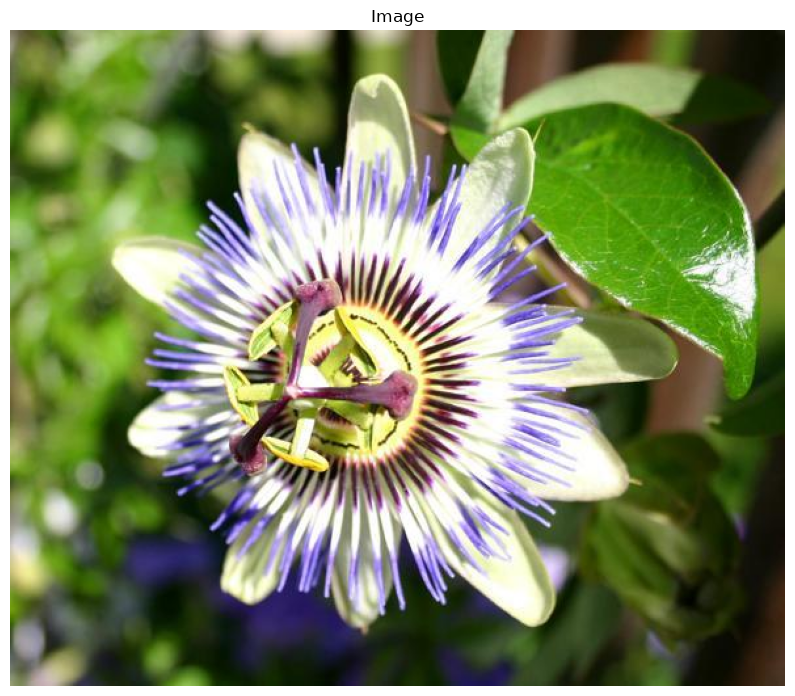

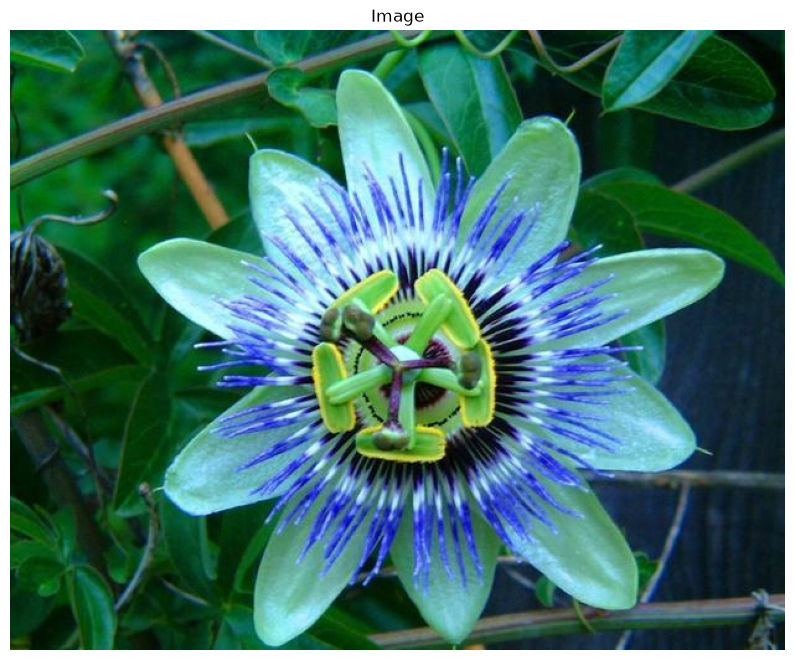

In [6]:
image1, *_ = train_dataset[0]
image2, *_ = train_dataset[1]
plot_image(image1)
plot_image(image2)

### Compute VLAD and Fisher Vectors

In [7]:
fisher_vector_1 = fisher_embedder.embed(image1)
vlad_vector_1 = vlad_embedder.embed(image1)
print(
    f"Shape of Fisher Vector: {fisher_vector_1.shape}, Shape of VLAD Vector: {vlad_vector_1.shape}"
)

fisher_vector_2 = fisher_embedder.embed(image2)
vlad_vector_2 = vlad_embedder.embed(image2)

Shape of Fisher Vector: (1, 16416), Shape of VLAD Vector: (1, 16384)


### Compute similarity scores using VLAD and Fisher Vectors

In [8]:
print("Cosine similarity using VLAD:", vlad_embedder.similarity_score(image1, image2))
print(
    "Cosine similarity using Fisher Vectors:",
    fisher_embedder.similarity_score(image1, image2),
)

Cosine similarity using VLAD: [[0.04543023]]


Cosine similarity using Fisher Vectors: [[0.03073282]]


## Use a Pipeline

We can combine both steps above by using the pipeline class.

In [9]:
pipeline = Pipeline([vlad_embedder, fisher_embedder])

### Compare images using the pipeline

The result is the similarity score of the concatenated VLAD and Fisher vectors.

In [10]:
sim_score = pipeline.similarity_score(image1, image2)
print("Scores using the pipeline:", sim_score)

Scores using the pipeline: [[0.04402345]]


This is equal to:

In [11]:
combined_vector_1 = np.hstack((vlad_vector_1, fisher_vector_1))
combined_vector_2 = np.hstack((vlad_vector_2, fisher_vector_2))
print(
    "Cosine similarity using concatenated vectors:",
    cosine_similarity(combined_vector_1, combined_vector_2),
)  # Cosine similarity was chosen as `similarity_func` for the embedders

Cosine similarity using concatenated vectors: [[0.04402345]]


You can also compare two batches of images at once. The shape is the similarity matrix of size (batch_1_size, batch_2_size).

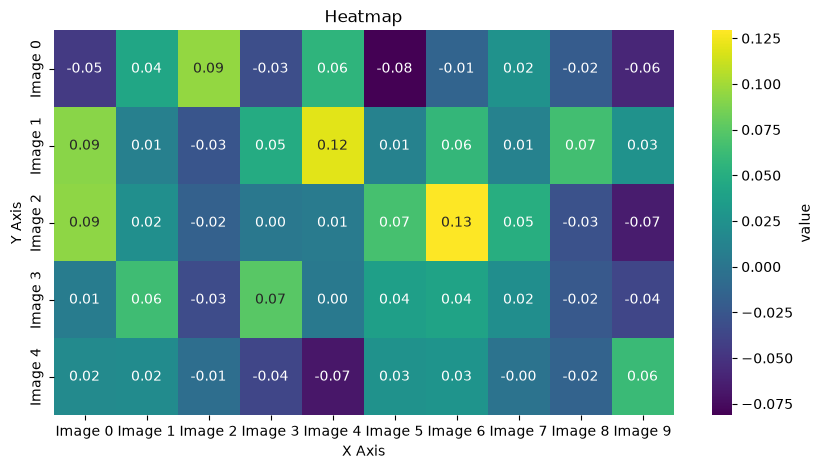

In [12]:
batch_1 = (train_dataset[i][0] for i in range(5))
batch_2 = (train_dataset[i][0] for i in range(5, 15))
similarity_matrix = pipeline.similarity_score(batch_1, batch_2)
plot_and_save_heatmap(
    similarity_matrix,
    x_tick_labels=[f"Image {i}" for i in range(10)],
    y_tick_labels=[f"Image {i}" for i in range(5)],
    figsize=(10, 5),
)

You can call the `embed` method, just like with `VLADEmbedder` and `FisherVectorEmbedder`. Each image is embedded using the embedders in the pipeline, and the end result is the concatenation of the vectors.

In [13]:
images_1_5 = [train_dataset[i][0] for i in range(5)]
embedding = pipeline.embed(images_1_5)
print("Shape of embedded batch:", embedding.shape)  # (num_images, dim_vlad + dim_fisher)

Shape of embedded batch: (5, 32800)


### Build an image store

The store embeds the images with the pipeline. Its paths are the image paths and its embeddings are the concatenated VLAD and Fisher vectors, L2-normalised since the store is built in the `cosine` space.

In [14]:
image_paths = train_dataset.image_paths[:5]
store = InMemoryImageEmbeddingStore(image_paths=image_paths, embedder=pipeline)
{
    os.path.basename(path): vector
    for path, vector in zip(store.paths, store.embeddings, strict=True)
}

{'image_00001.jpg': array([0.000000e+00, 0.000000e+00, 0.000000e+00, ..., 7.665080e-06,
        8.159516e-06, 9.737308e-06], shape=(32800,), dtype=float32),
 'image_00002.jpg': array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         5.7570269e-05, -2.0205942e-05,  4.3448621e-05],
       shape=(32800,), dtype=float32),
 'image_00003.jpg': array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
         2.4135752e-05,  3.1125095e-05, -7.3516021e-05],
       shape=(32800,), dtype=float32),
 'image_00004.jpg': array([ 0.        ,  0.        ,  0.        , ...,  0.00560213,
         0.00451446, -0.00201603], shape=(32800,), dtype=float32),
 'image_00005.jpg': array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
        -6.0773491e-05,  7.3310119e-05, -5.7626447e-05],
       shape=(32800,), dtype=float32)}

Print the pipeline to see the embedders it contains.

In [15]:
print(pipeline)

Pipeline(
embedders=[VLADEmbedder(feature_extractor=DeepConvFeature, 
similarity_func=cosine, 
Number of cluster=32, 
Power Norm Weight=1, 
Norm Order=2)
FisherVectorEmbedder(feature_extractor=DeepConvFeature, 
similarity_func=cosine, 
Number of cluster=32, 
Power Norm Weight=0.5, 
Norm Order=2)],
similarity_func=cosine)
